CONTEXT : A  complex  modern  semiconductor  manufacturing  process  is  normally  under  constant  surveillance  via  the  monitoring  of signals/variables  collected  from  sensors  and  or  process  measurement  points.  However,  not  all  of  these  signals  are  equally  valuable  in  a specific  monitoring  system.  The  measured  signals  contain  a  combination  of  useful  information,  irrelevant  information  as  well  as  noise. Engineers typically have a much larger number of signals than are actually required. If we consider each type of signal as a feature, then feature selection may be applied to identify the most relevant signals. The Process Engineers may then use these signals to determine key factors contributing to yield excursions downstream in the process. This will enable an increase in process throughput, decreased time to learning and reduce the per unit production costs. These signals can be used as features to predict the yield type. And by analysing and trying out different combinations of features, essential signals that are impacting the yield type can be identified.

OBJECTIVE : We  will  build  a  classifier  to  predict  the  Pass/Fail  yield  of  a  particular  process  entity  and  analyse  whether  all  the features are required to build the model or not

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. IMPORT AND UNDERSTAND THE DATA

In [2]:
#A. Import ‘signal-data.csv’ as DataFrame.
signal_data = pd.read_csv("signal-data.csv")
signal_data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [3]:
signal_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [4]:
#B. Print 5 point summary and share at least 2 observations.
signal_data.describe()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [5]:
signal_data_c = signal_data.copy(deep=True)
signal_data_c.head(10)

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
5,2008-07-19 17:53:00,2946.25,2432.84,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5287,...,44.0077,0.4949,0.0189,0.0044,3.8276,0.0342,0.0151,0.0052,44.0077,-1
6,2008-07-19 19:44:00,3030.27,2430.12,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.5816,...,NaN,0.5010,0.0143,0.0042,2.8515,0.0342,0.0151,0.0052,44.0077,-1
7,2008-07-19 19:45:00,3058.88,2690.15,2248.9000,1004.4692,0.7884,100.0,106.2400,0.1185,1.5153,...,95.0310,0.4984,0.0106,0.0034,2.1261,0.0204,0.0194,0.0063,95.0310,-1
8,2008-07-19 20:24:00,2967.68,2600.47,2248.9000,1004.4692,0.7884,100.0,106.2400,0.1185,1.5358,...,111.6525,0.4993,0.0172,0.0046,3.4456,0.0111,0.0124,0.0045,111.6525,-1
9,2008-07-19 21:35:00,3016.11,2428.37,2248.9000,1004.4692,0.7884,100.0,106.2400,0.1185,1.5381,...,90.2294,0.4967,0.0152,0.0038,3.0687,0.0212,0.0191,0.0073,90.2294,-1


2. DATA CLEANSING

In [6]:
#A. Write a for loop which will remove all the features with 20%+ Null values and impute rest with mean of the feature.
n_list = [(signal_data.isna().sum() / len(signal_data)) * 100]
n_list

[Time         0.000000
 0            0.382897
 1            0.446713
 2            0.893427
 3            0.893427
                ...   
 586          0.063816
 587          0.063816
 588          0.063816
 589          0.063816
 Pass/Fail    0.000000
 Length: 592, dtype: float64]

In [7]:
signal_data.drop(columns='Time',inplace=True)
signal_columns = list(signal_data.columns)
signal_columns

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138'

In [8]:
for c in signal_columns:
    if(((signal_data[c].isnull().sum()/len(signal_data))*100) > 20):
        signal_data.drop(columns=c,inplace=True)
    else:
        signal_data[c] = signal_data[c].replace(' ',np.nan)
        med = signal_data[c].median()
        signal_data[c] = signal_data[c].fillna(med)
signal_data.isnull().sum()    

0            0
1            0
2            0
3            0
4            0
            ..
586          0
587          0
588          0
589          0
Pass/Fail    0
Length: 559, dtype: int64

In [9]:
signal_data.shape

(1567, 559)

In [10]:
signal_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 559 entries, 0 to Pass/Fail
dtypes: float64(558), int64(1)
memory usage: 6.7 MB


In [11]:
signal_data.head()

,0,1,2,3,4,5,6,7,8,9,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [12]:
#B. Identify and drop the features which are having same value for all the rows.
def feature_removal(df):
    return [f for f in df.columns if df[f].nunique() == 1]
drop_feature = feature_removal(signal_data)
drop_feature

['5',
 '13',
 '42',
 '49',
 '52',
 '69',
 '97',
 '141',
 '149',
 '178',
 '179',
 '186',
 '189',
 '190',
 '191',
 '192',
 '193',
 '194',
 '226',
 '229',
 '230',
 '231',
 '232',
 '233',
 '234',
 '235',
 '236',
 '237',
 '240',
 '241',
 '242',
 '243',
 '256',
 '257',
 '258',
 '259',
 '260',
 '261',
 '262',
 '263',
 '264',
 '265',
 '266',
 '276',
 '284',
 '313',
 '314',
 '315',
 '322',
 '325',
 '326',
 '327',
 '328',
 '329',
 '330',
 '364',
 '369',
 '370',
 '371',
 '372',
 '373',
 '374',
 '375',
 '378',
 '379',
 '380',
 '381',
 '394',
 '395',
 '396',
 '397',
 '398',
 '399',
 '400',
 '401',
 '402',
 '403',
 '404',
 '414',
 '422',
 '449',
 '450',
 '451',
 '458',
 '461',
 '462',
 '463',
 '464',
 '465',
 '466',
 '481',
 '498',
 '501',
 '502',
 '503',
 '504',
 '505',
 '506',
 '507',
 '508',
 '509',
 '512',
 '513',
 '514',
 '515',
 '528',
 '529',
 '530',
 '531',
 '532',
 '533',
 '534',
 '535',
 '536',
 '537',
 '538']

In [13]:
signal_data.drop(drop_feature,axis=1,inplace=True)
signal_data.head(10)

,0,1,2,3,4,6,7,8,9,10,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
5,2946.25,2432.84,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5287,0.0167,0.0055,...,13.7755,0.4949,0.0189,0.0044,3.8276,0.0342,0.0151,0.0052,44.0077,-1
6,3030.27,2430.12,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.5816,-0.0270,0.0105,...,8.3645,0.5010,0.0143,0.0042,2.8515,0.0342,0.0151,0.0052,44.0077,-1
7,3058.88,2690.15,2248.9000,1004.4692,0.7884,106.2400,0.1185,1.5153,0.0157,0.0007,...,16.0862,0.4984,0.0106,0.0034,2.1261,0.0204,0.0194,0.0063,95.0310,-1
8,2967.68,2600.47,2248.9000,1004.4692,0.7884,106.2400,0.1185,1.5358,0.0111,-0.0066,...,14.2892,0.4993,0.0172,0.0046,3.4456,0.0111,0.0124,0.0045,111.6525,-1
9,3016.11,2428.37,2248.9000,1004.4692,0.7884,106.2400,0.1185,1.5381,0.0159,0.0049,...,7.4181,0.4967,0.0152,0.0038,3.0687,0.0212,0.0191,0.0073,90.2294,-1


In [14]:
#C. Drop other features if required using relevant functional knowledge. Clearly justify the same.
signal_data['Pass/Fail'] = signal_data['Pass/Fail'].replace([-1,1],[0,1])
signal_data.head()

,0,1,2,3,4,6,7,8,9,10,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0


In [15]:
from sklearn.decomposition import PCA
pca350 = PCA(n_components=350)
signal_reduced_data = pca350.fit_transform(signal_data)
signal_reduced_data.shape

(1567, 350)

<AxesSubplot: >

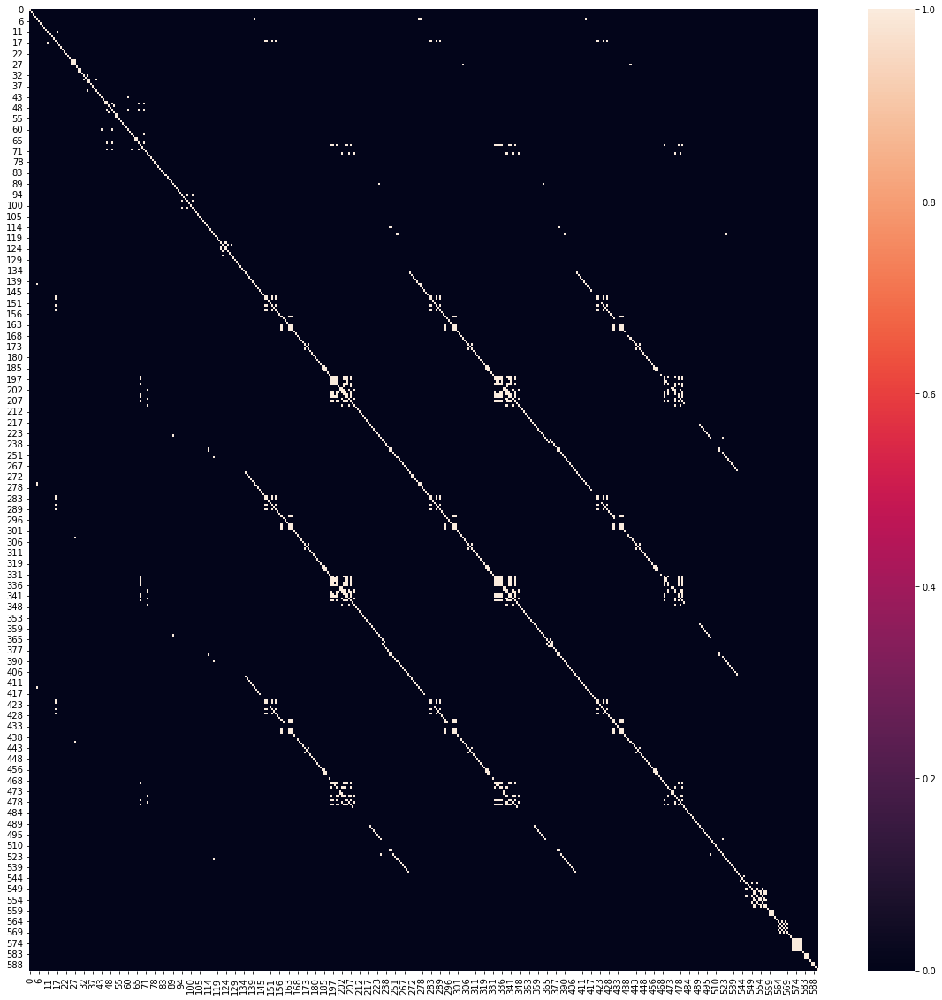

In [16]:
#D. Check for multi-collinearity in the data and take necessary action.
plt.figure(figsize=(20,20))
corr = signal_data.corr()
sns.heatmap(corr>0.7)

In [17]:
cor_mat = signal_data.corr().abs()
up = cor_mat.where(np.triu(np.ones(cor_mat.shape),k=1).astype(bool))
drop_feat = [column for column in up.columns if any(up[column] > 0.70)]
signal_data.drop(drop_feat,axis=1,inplace=True)
signal_data.shape

(1567, 202)

E. Make all relevant modifications on the data using both functional/logical reasoning/assumptions.

After observing Q2.B, we could see that there are a total of 116 features/columns that have the same values for their records. So it would be better to drop these features to avoid overfitting or multicollinearity.

After observing Q2.C, there seems to too many features in the dataset. The dataset contains 443 features after dropping some features that have same values for their rows. The number of features seems to be more than required for the model to be trained. So PCA is the best technique to reduce the dimension of the dataset. 

After observing Q2.D, even after dropping the features with similar rows or duplicate, there are 148 features that lead to multicollinearity after observing the heatmap. So it is better to drop these features which have collinearity of above 0.7 or 70%.

3. DATA ANALYSIS AND VISUALIZATION

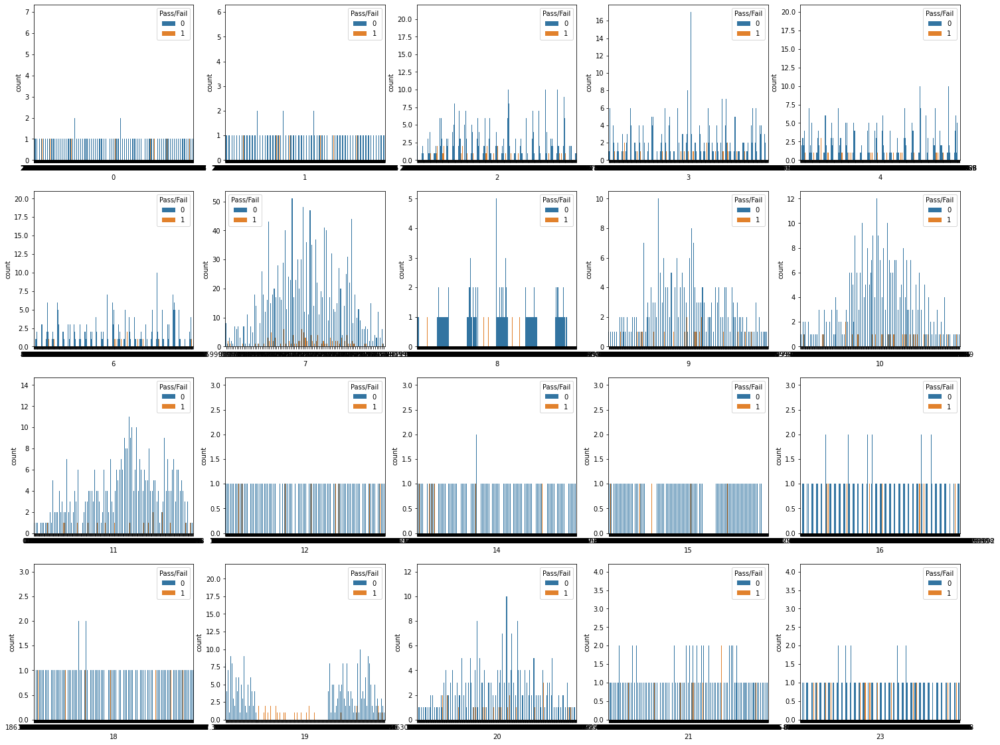

In [18]:
#A. Perform a detailed univariate Analysis with appropriate detailed comments after each analysis.
cols = list(signal_data.columns)
column_subset1 = cols[:20]
plt.figure(figsize=(25,25))
index=1
for c in column_subset1:
    plt.subplot(5,5,index)
    sns.countplot(data=signal_data,x=c,hue='Pass/Fail')
    index+=1

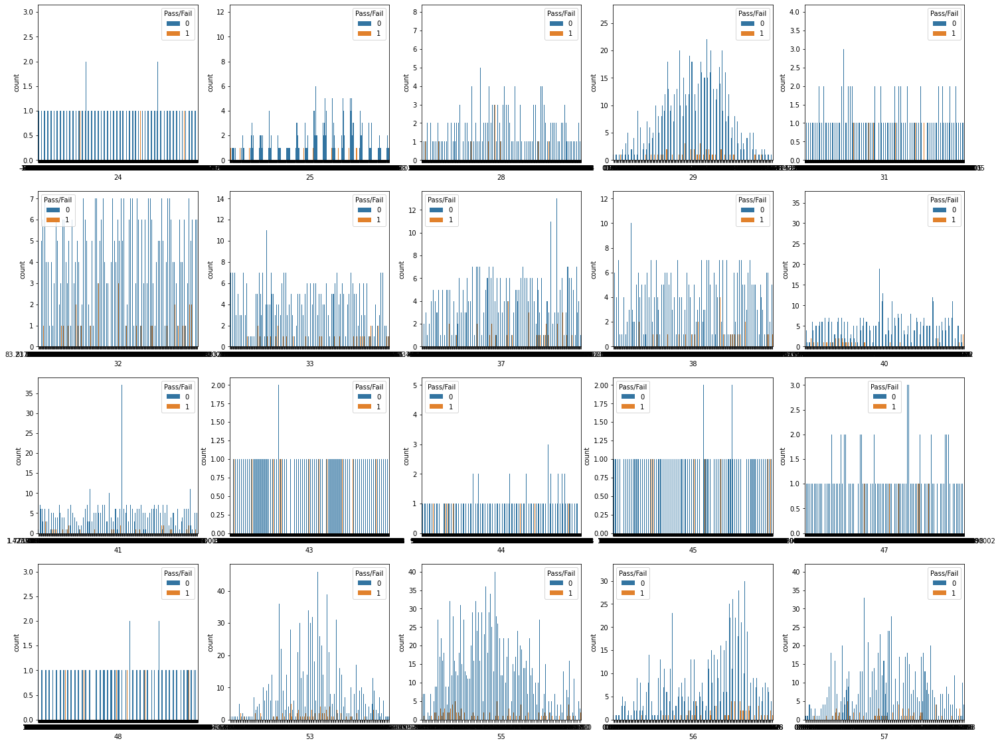

In [19]:
column_subset2 = cols[20:40]
plt.figure(figsize=(25,25))
index=1
for c in column_subset2:
    plt.subplot(5,5,index)
    sns.countplot(data=signal_data,x=c,hue='Pass/Fail')
    index+=1

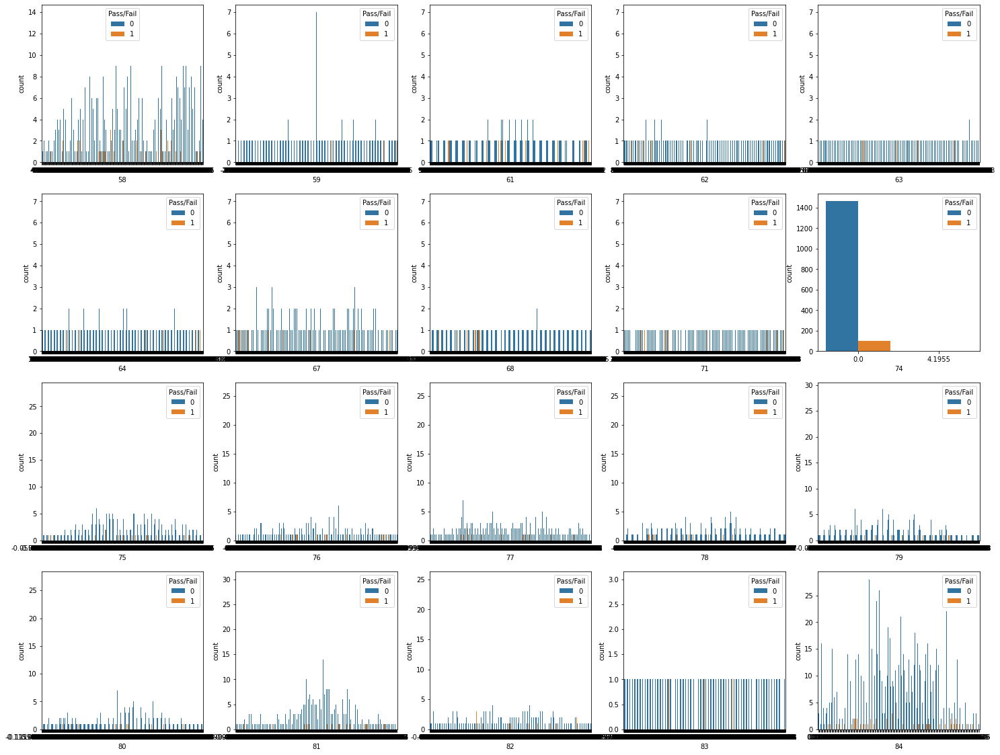

In [20]:
column_subset3 = cols[40:60]
plt.figure(figsize=(25,25))
index=1
for c in column_subset3:
    plt.subplot(5,5,index)
    sns.countplot(data=signal_data,x=c,hue='Pass/Fail')
    index+=1

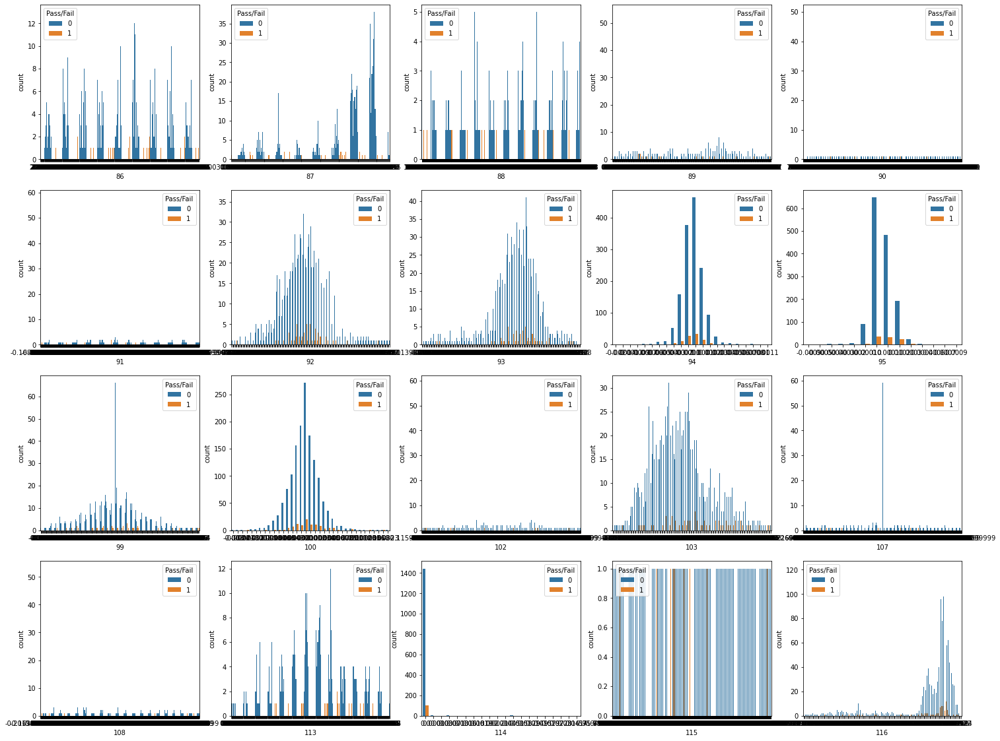

In [21]:
column_subset4 = cols[60:80]
plt.figure(figsize=(25,25))
index=1
for c in column_subset4:
    plt.subplot(5,5,index)
    sns.countplot(data=signal_data,x=c,hue='Pass/Fail')
    index+=1

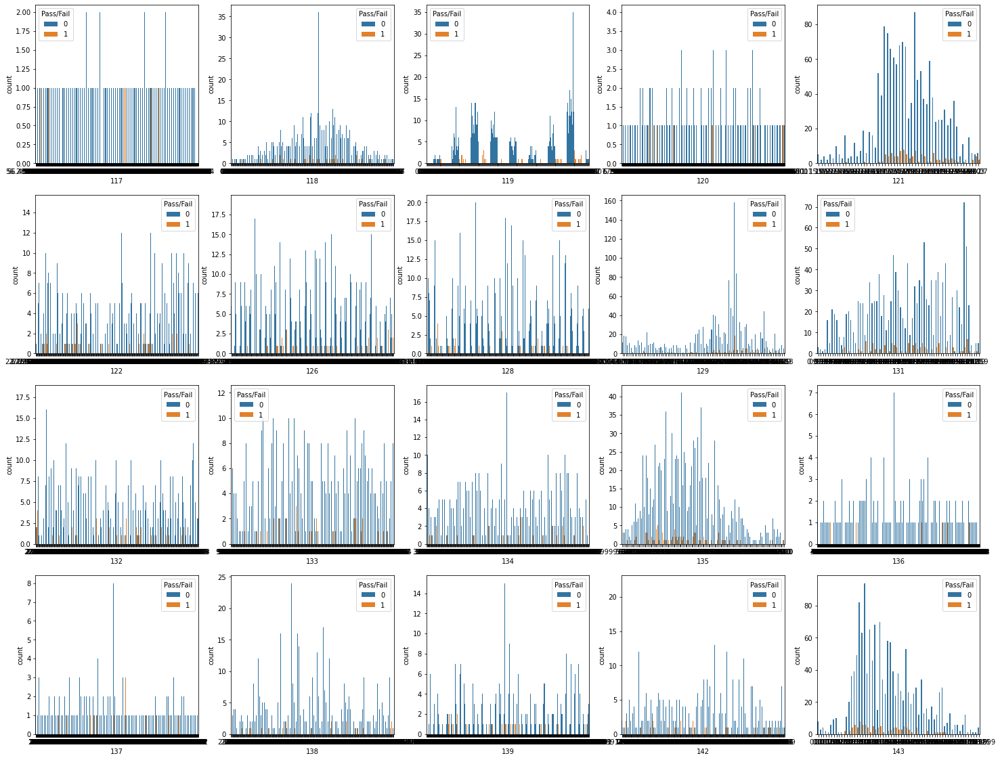

In [22]:
column_subset5 = cols[80:100]
plt.figure(figsize=(25,25))
index=1
for c in column_subset5:
    plt.subplot(5,5,index)
    sns.countplot(data=signal_data,x=c,hue='Pass/Fail')
    index+=1

In the above univariate analysis, we have used the count plot visualization technique to observe each feature of the dataset. 

i) Features [0,1,12,14,15,16,21,23,43,45] show a uniform distribution in there visulaization

ii) Features [7,10,29,303] show a nearly perfect normal distribution

iii) Features [445,435,305] are slightly left skewed

iv) Features [421] are slightly right skewed

v) These individual features have got a lot of fails as there result more than pass  

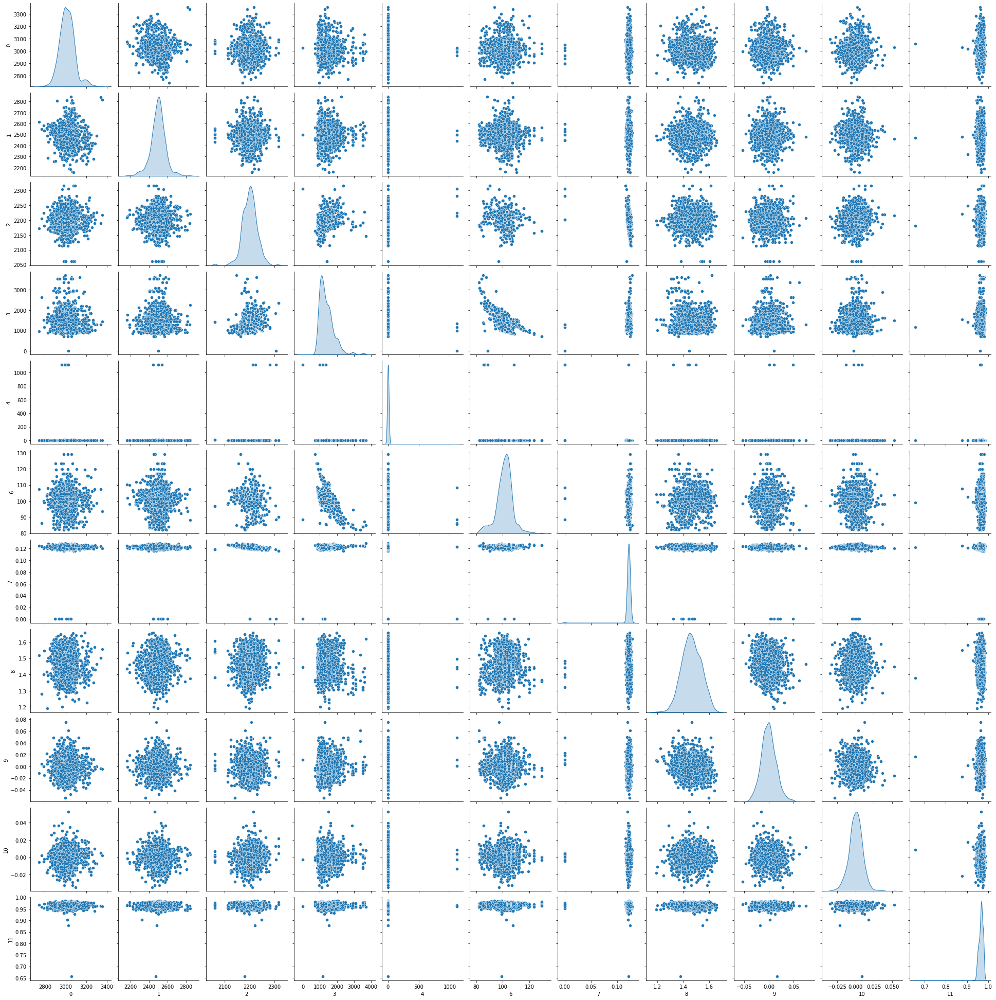

In [23]:
#B. Perform bivariate and multivariate analysis with appropriate detailed comments after each analysis.
sns.pairplot(data=signal_data[cols[:11]],diag_kind='kde')

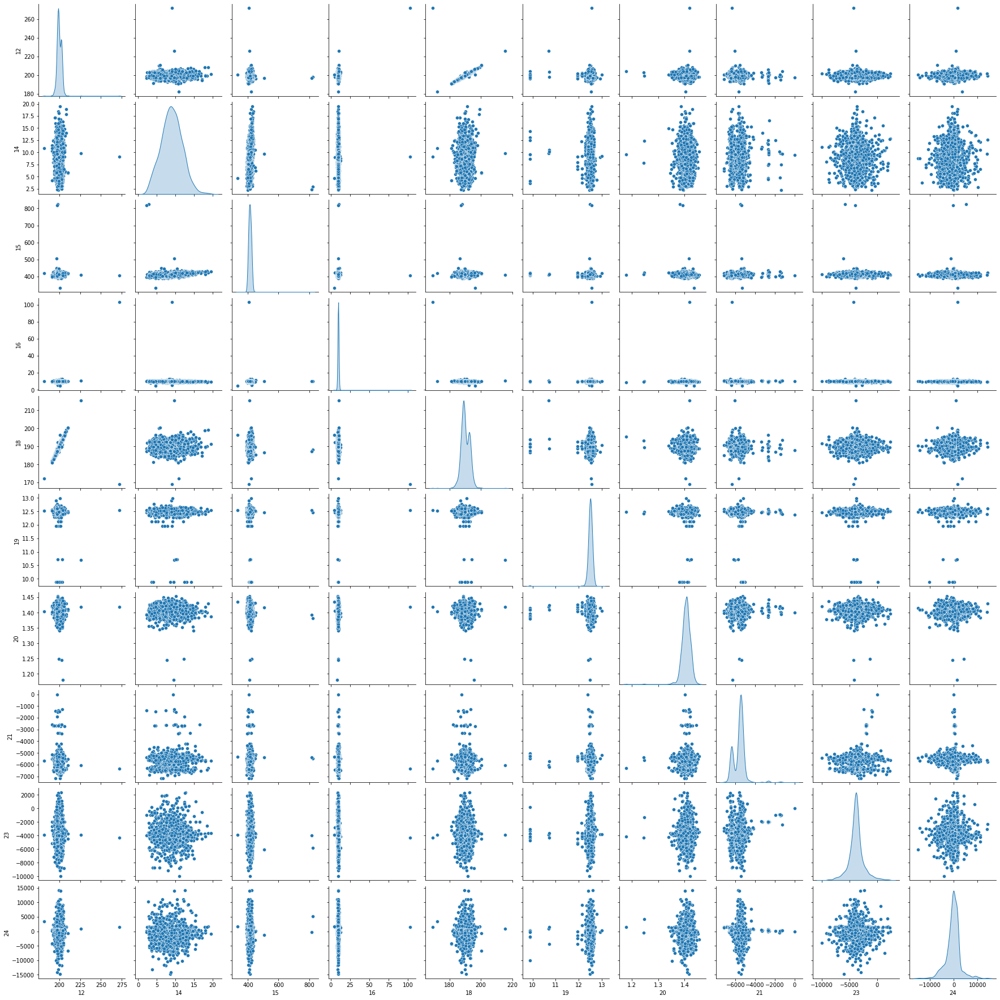

In [24]:
sns.pairplot(data=signal_data[cols[11:21]],diag_kind='kde')

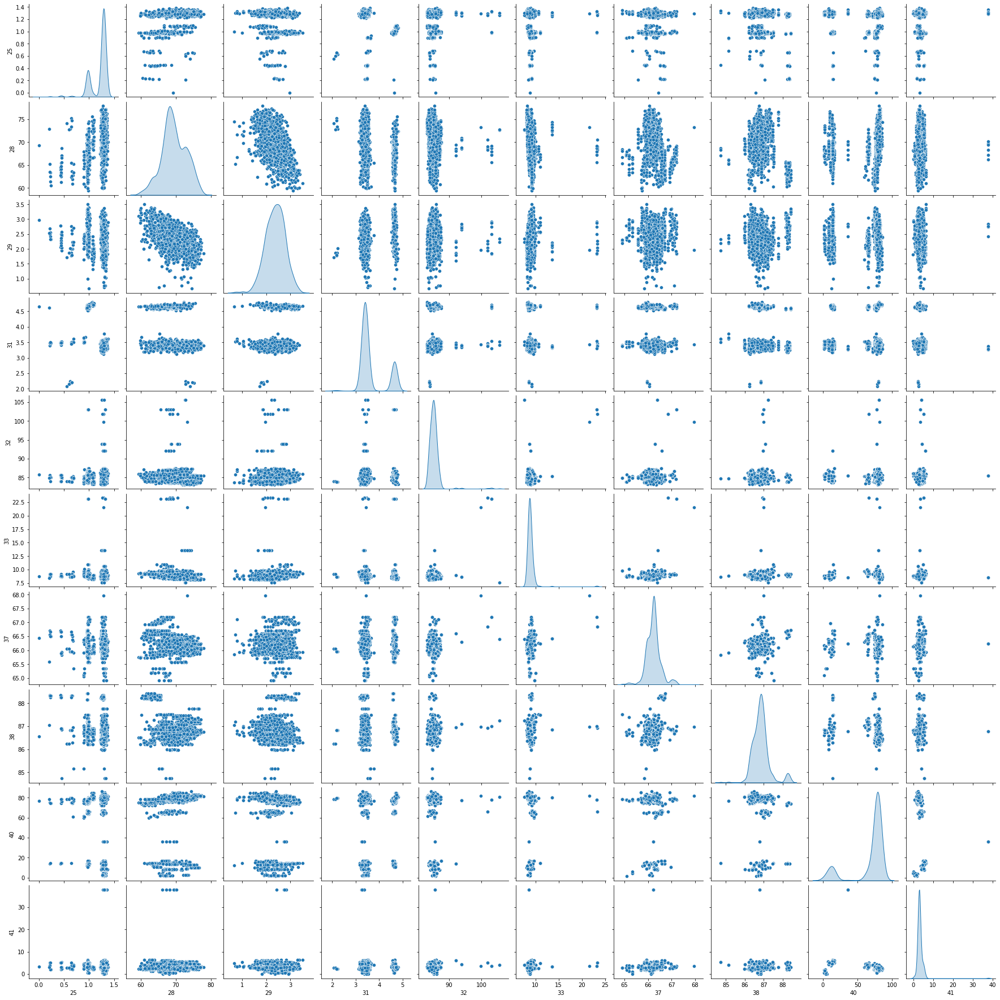

In [25]:
sns.pairplot(data=signal_data[cols[21:31]],diag_kind='kde')

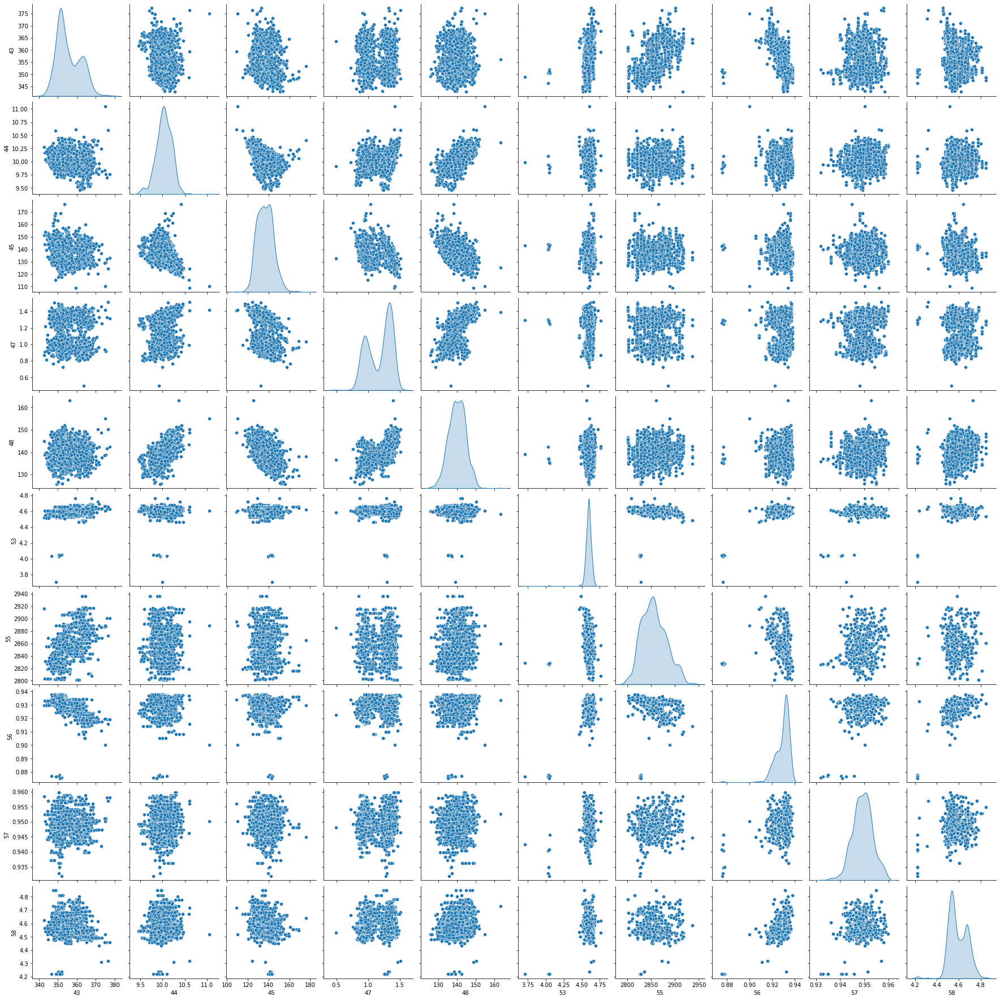

In [26]:
sns.pairplot(data=signal_data[cols[31:41]],diag_kind='kde')

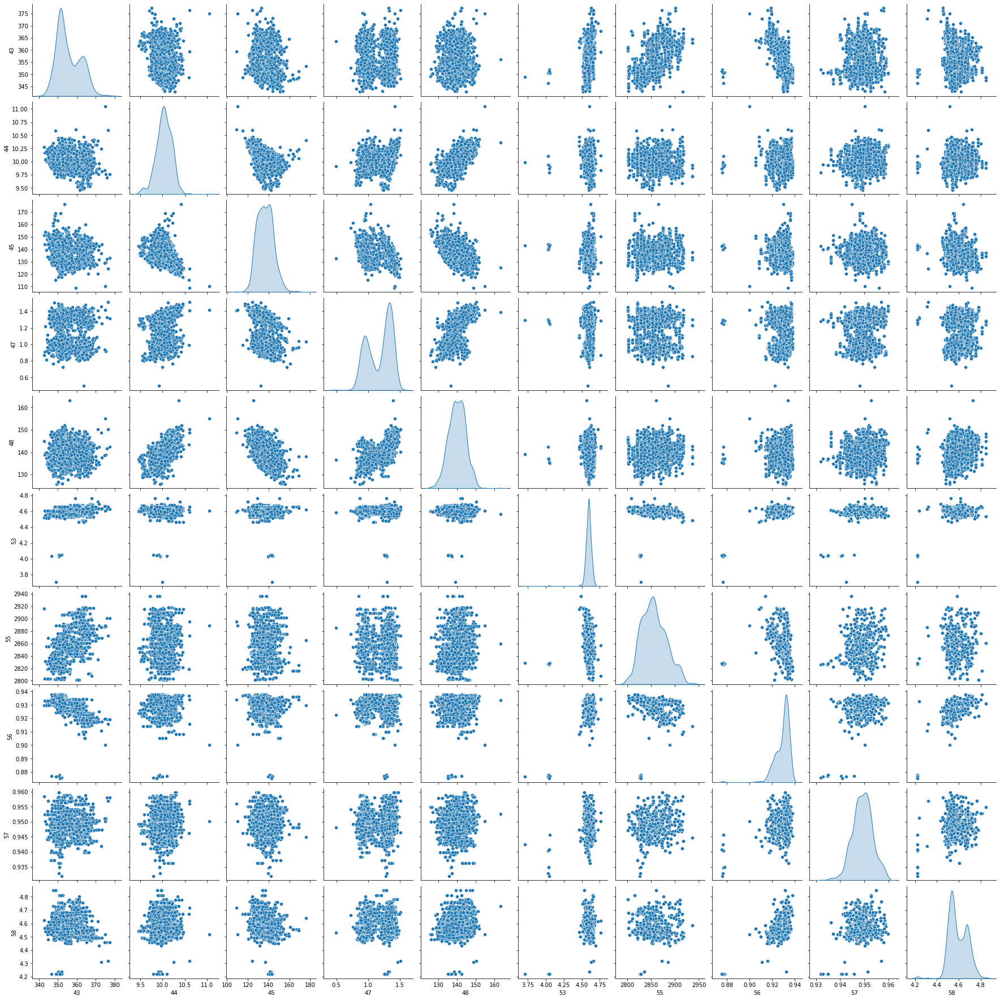

In [27]:
sns.pairplot(data=signal_data[cols[31:41]],diag_kind='kde')

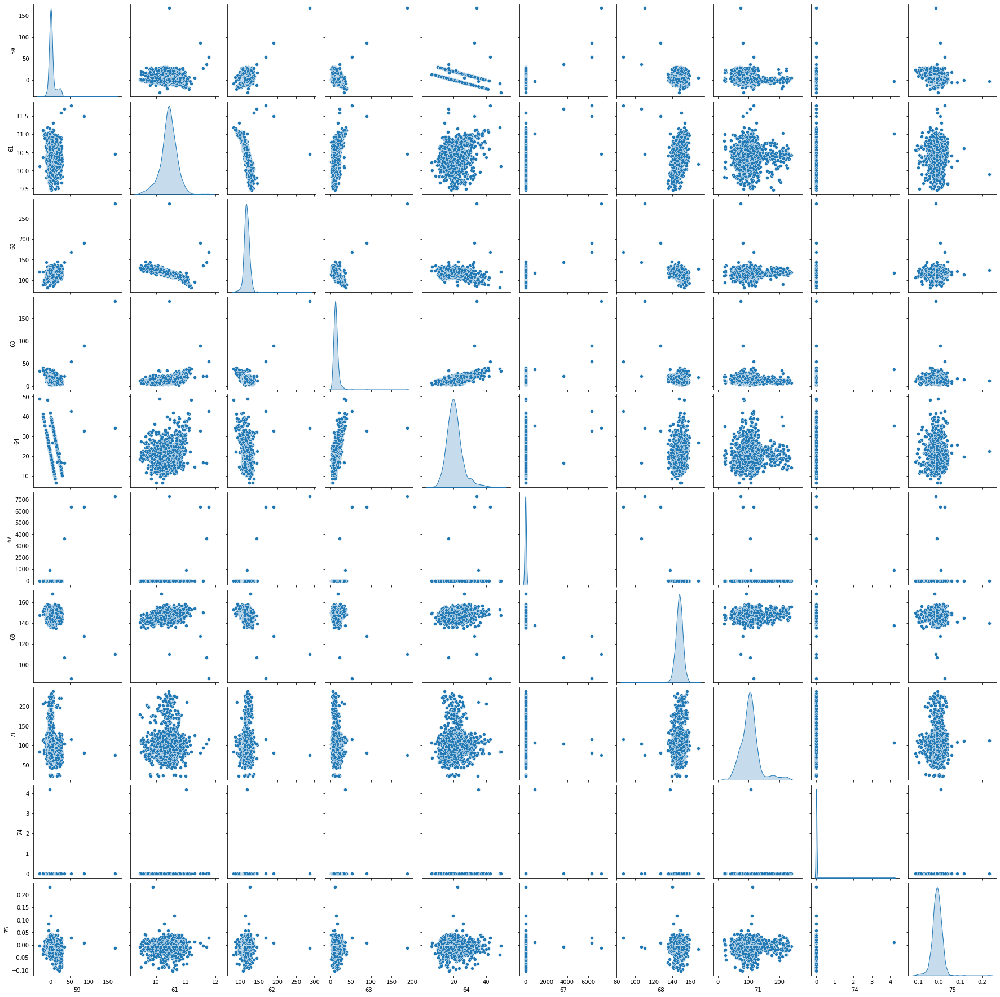

In [28]:
sns.pairplot(data=signal_data[cols[41:51]],diag_kind='kde')

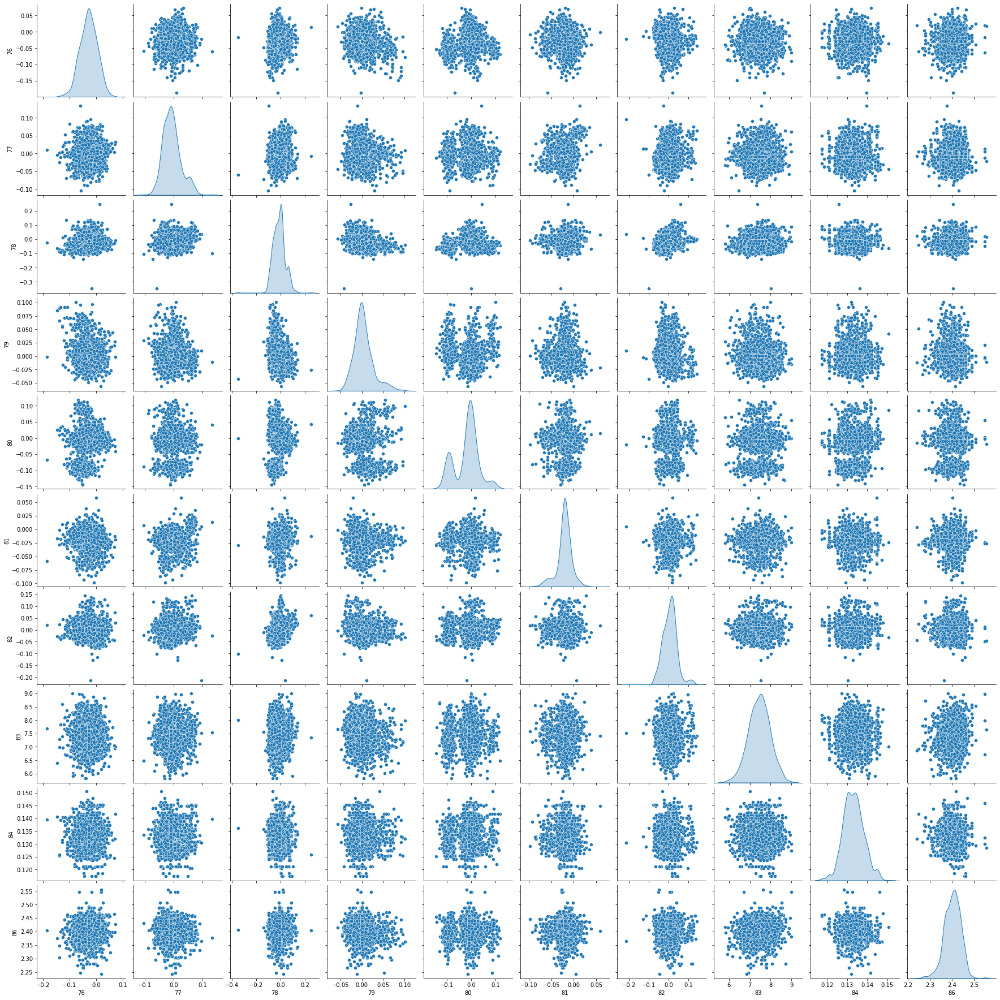

In [29]:
sns.pairplot(data=signal_data[cols[51:61]],diag_kind='kde')

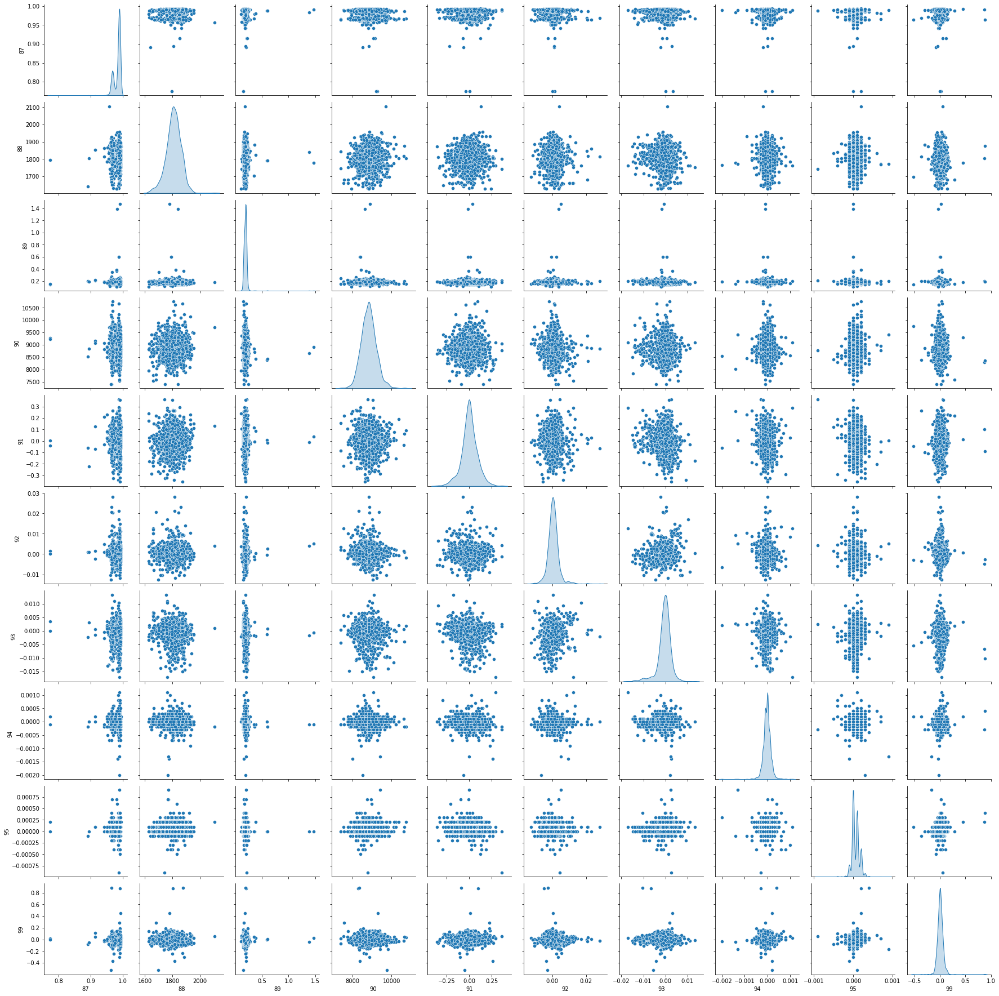

In [30]:
sns.pairplot(data=signal_data[cols[61:71]],diag_kind='kde')

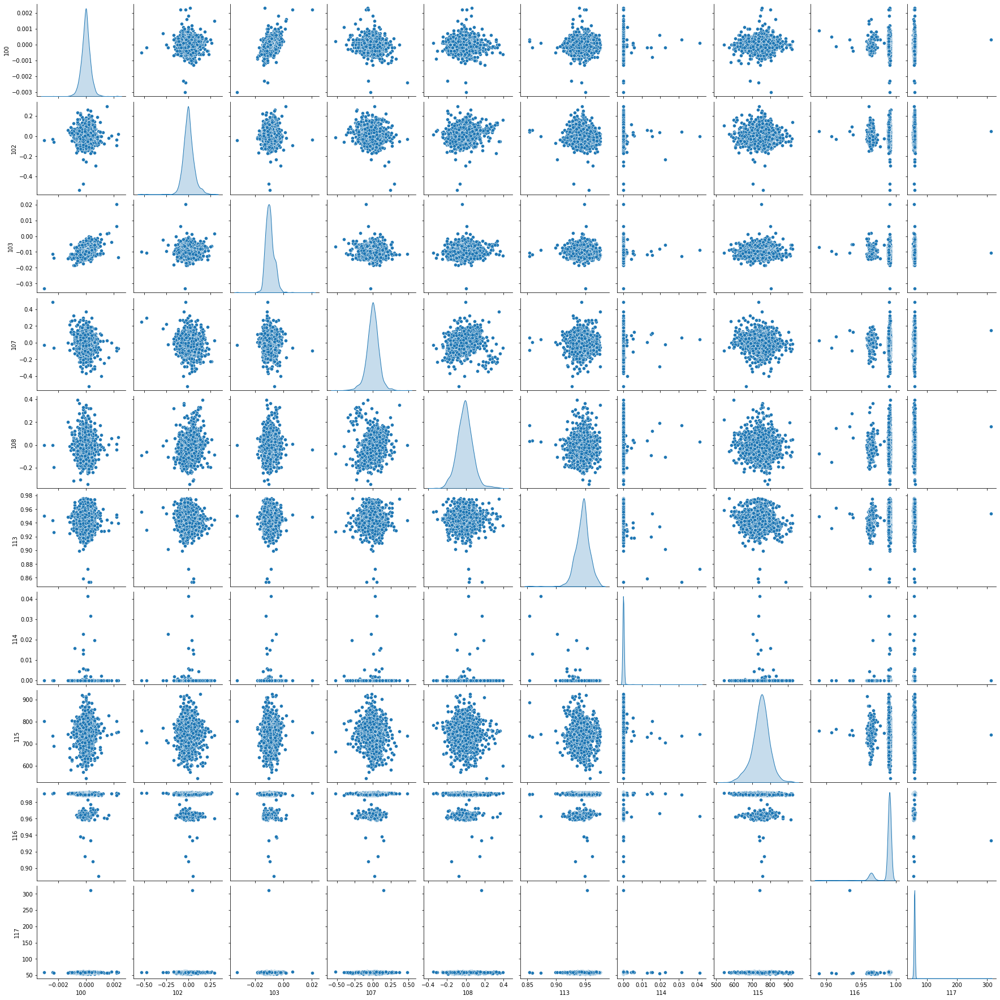

In [31]:
sns.pairplot(data=signal_data[cols[71:81]],diag_kind='kde')

In the above bivariate and multivariate analysis, we have used pair plot visualization technique to visualize individual paired features.

i) Every features individually are normally distributed

ii) Some are left skewed and right skewed and some features display a bimodal visualization

iii) The feature 117 possess a constant value of nearly 10 with other features.

iv) Many features show a distributed data cloud and catplot visualization

4. DATA PRE-PROCESSING

In [32]:
#A. Segregate predictors vs target attributes.
X = signal_data.drop(columns=['Pass/Fail'])
Y = signal_data['Pass/Fail']
X.head()

,0,1,2,3,4,6,7,8,9,10,...,564,565,570,571,572,582,583,586,587,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,5.16,0.11955,533.8500,2.1113,8.95,0.5005,0.0118,0.0205,0.0148,71.9005
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,5.16,0.11955,535.0164,2.4335,5.92,0.5019,0.0223,0.0096,0.0201,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,1.10,0.62190,535.0245,2.0293,11.21,0.4958,0.0157,0.0584,0.0484,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,7.32,0.16300,530.5682,2.0253,9.33,0.4990,0.0103,0.0202,0.0149,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,5.16,0.11955,532.0155,2.0275,8.83,0.4800,0.4766,0.0202,0.0149,73.8432


In [33]:
Y.head()

0    0
1    0
2    1
3    0
4    0
Name: Pass/Fail, dtype: int64

In [34]:
#B. Check for target balancing and fix it if found imbalanced.
Y.value_counts()

0    1463
1     104
Name: Pass/Fail, dtype: int64

<AxesSubplot: >

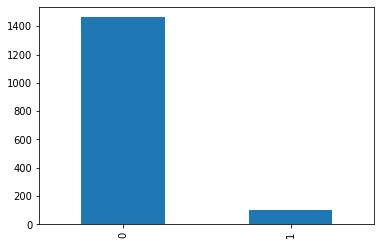

In [35]:
Y.value_counts().plot(kind='bar')

In [36]:
from imblearn.over_sampling import SMOTE
smt = SMOTE(sampling_strategy=1,k_neighbors=5,random_state=1)
X_smot, Y_smot = smt.fit_resample(X,Y)
Y_smot.value_counts()

0    1463
1    1463
Name: Pass/Fail, dtype: int64

In [37]:
#C. Perform train-test split and standardise the data or vice versa if required
from scipy.stats import zscore
X_scaled = X_smot.apply(zscore)
X_scaled.head()

,0,1,2,3,4,6,7,8,9,10,...,564,565,570,571,572,582,583,586,587,589
0,0.304670,0.965756,-0.462366,0.079582,-0.036100,-0.676435,0.327972,0.532946,1.350020,-0.452213,...,-0.491907,-0.361178,0.198709,0.055685,-0.206363,0.042688,-0.271640,-0.103415,-0.279046,-0.329483
1,1.209385,-0.410971,1.130173,0.220741,-0.049024,0.215752,0.403461,0.471443,0.097505,-1.785835,...,-0.491907,-0.361178,0.260339,1.167259,-0.249734,0.472498,0.532442,-1.082285,0.361928,1.341728
2,-1.066981,0.909216,-0.511691,0.850457,-0.032448,-1.077353,0.312874,-0.364355,0.442509,0.097613,...,-2.292124,6.047421,0.260767,-0.227210,-0.174014,-1.400245,0.027019,3.300178,3.784488,-0.195107
3,-0.284197,-0.205423,-0.040811,-1.267502,-0.037069,0.572891,-0.049474,0.338977,-0.795006,-0.440515,...,0.465844,0.193124,0.025303,-0.241010,-0.200924,-0.417823,-0.386509,-0.130357,-0.266952,-0.305664
4,0.322945,0.114458,1.240020,-0.147756,-0.031883,-0.151421,0.222287,0.573947,-0.097497,-0.896754,...,-0.491907,-0.361178,0.101776,-0.233420,-0.208081,-6.250956,35.322406,-0.130357,-0.266952,-0.305664


In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_smot, test_size=0.30, random_state=1)
X_train.head()

,0,1,2,3,4,6,7,8,9,10,...,564,565,570,571,572,582,583,586,587,589
608,0.786254,2.833793,-0.002263,-0.991058,-0.035243,0.351769,-0.124964,-0.228735,-0.607504,-0.288435,...,-0.354452,0.107650,0.153363,-0.286549,-0.201927,-0.663428,0.310362,0.318666,-0.170201,-0.446114
348,-0.253087,-1.597190,0.688310,0.673803,-0.048776,-0.578766,-0.140061,-0.995147,0.397508,1.595012,...,-0.571720,-0.767496,0.257359,-0.726418,-0.190904,-2.167763,0.095940,-2.052174,-0.242764,-1.211048
2719,-0.454492,-0.592129,0.772053,0.619437,-0.026078,-0.021846,-0.153882,-1.341636,-0.226388,-2.157033,...,-0.098734,0.705053,0.270695,0.697483,-0.239418,-0.156620,-0.155758,-0.209993,-1.084344,-0.686372
1621,-0.684656,-1.563607,1.021205,0.130018,-0.042052,-0.047728,-0.238938,0.171736,1.644279,0.027926,...,0.435866,-0.364342,0.010172,1.159935,-0.208893,0.364702,0.205550,-0.938953,-1.063023,-0.305158
612,-1.645106,-0.202498,-1.054694,-1.183670,-0.037795,0.428897,0.207189,1.051772,0.870014,0.062518,...,-0.669268,-0.041609,0.070792,0.151939,-0.201067,2.867153,2.178897,0.318666,-0.170201,-0.446114


In [39]:
X_test.head()

,0,1,2,3,4,6,7,8,9,10,...,564,565,570,571,572,582,583,586,587,589
1117,-0.356184,1.407768,0.224473,1.331356,-0.019043,-0.989964,0.388363,0.222281,-0.315000,-0.440515,...,-1.059463,-0.312063,0.132417,0.225768,-0.182888,0.871607,0.049993,-0.561419,-0.581392,-0.230909
192,-0.731741,-0.815104,-2.270445,-0.693687,-0.035864,0.198569,0.509146,-1.304235,-0.990008,1.056884,...,-0.491907,-0.361178,0.052441,0.860213,-0.205647,-1.707252,-0.034244,-0.938598,0.240990,0.879002
2190,-0.057604,-0.138187,-0.070141,0.358011,-0.037933,-0.278579,0.043563,-1.144583,0.787295,-0.327405,...,-0.505641,-0.431096,0.162442,-1.599354,-0.205014,-0.137530,0.302033,1.642293,-0.406346,-0.739754
45,-1.342372,-0.674033,-1.253660,-1.274805,-0.043295,0.626536,0.010917,1.054926,-1.987520,0.530455,...,-0.137184,-0.249552,-0.085420,0.233358,-0.210371,0.441797,-0.286956,-0.714086,-0.194389,0.178997
2473,-0.052623,0.179675,1.057432,0.957424,-0.029368,-1.005261,0.004620,-0.357808,0.520019,0.645742,...,0.423651,0.833863,0.218438,0.357136,-0.235306,0.364623,0.173101,-0.782058,0.055455,1.252514


In [40]:
#D. Check if the train and test data have similar statistical characteristics when compared with original data.
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
0,2048.0,0.015340,1.028385,-3.708860,-0.649282,-0.130534,0.570587,4.844566
1,2048.0,-0.020367,1.001295,-4.677765,-0.577126,0.040650,0.539046,4.801818
2,2048.0,0.010742,0.998263,-5.202922,-0.662231,-0.022463,0.611210,4.295356
3,2048.0,-0.004942,0.992800,-3.712114,-0.732378,-0.216487,0.513111,6.014124
4,2048.0,0.015983,1.195210,-0.052626,-0.042471,-0.037157,-0.032653,27.068760
...,...,...,...,...,...,...,...,...
582,2048.0,0.004686,0.999839,-6.926372,-0.602027,0.049786,0.656702,2.897853
583,2048.0,-0.001695,0.868475,-0.715800,-0.271640,-0.107931,0.108976,34.924194
586,2048.0,0.004309,1.009521,-2.483236,-0.608566,-0.070381,0.526089,7.287501
587,2048.0,0.016240,1.009714,-1.681933,-0.678143,-0.141527,0.470773,7.594051


In [41]:
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
0,878.0,-0.035783,0.930624,-2.682493,-0.655116,-0.172590,0.513235,3.443124
1,878.0,0.047509,0.996494,-4.275024,-0.543172,0.084711,0.580214,4.899022
2,878.0,-0.025058,1.004730,-5.202922,-0.711900,-0.067934,0.585096,4.295356
3,878.0,0.011527,1.017634,-1.801589,-0.707323,-0.210686,0.510050,6.270201
4,878.0,-0.037283,0.008528,-0.051647,-0.043400,-0.037355,-0.033178,0.025484
...,...,...,...,...,...,...,...,...
582,878.0,-0.010929,1.001430,-6.250956,-0.663428,0.019564,0.640508,2.897853
583,878.0,0.003953,1.255335,-0.631563,-0.278800,-0.113633,0.088430,35.322406
586,878.0,-0.010052,0.978509,-3.462106,-0.650939,-0.077677,0.532309,7.287501
587,878.0,-0.037881,0.977067,-1.560994,-0.714425,-0.191177,0.444891,6.408854


5. MODEL TRAINING, TESTING AND TUNING

In [42]:
#A. Use any Supervised Learning technique to train a model.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,Y_train)
knn_pred = knn.predict(X_test)
print("Training accuracy = ",knn.score(X_train,Y_train))
print("Testing accuracy = ",knn.score(X_test,Y_test))

Training accuracy =  0.759765625
Testing accuracy =  0.6583143507972665


In [43]:
#B. Use cross validation techniques
#K-fold cross validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kfold = KFold(n_splits=50)
res = cross_val_score(knn,X_scaled,Y_smot,cv=kfold)
print(res)

[0.25423729 0.22033898 0.13559322 0.20338983 0.3559322  0.28813559
 0.22033898 0.16949153 0.22033898 0.13559322 0.3559322  0.16949153
 0.11864407 0.11864407 0.11864407 0.33898305 0.42372881 0.23728814
 0.20338983 0.11864407 0.11864407 0.08474576 0.3220339  0.28813559
 0.42372881 0.55932203 0.63793103 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]


In [44]:
#C. Apply hyper-parameter tuning techniques to get the best accuracy.
from sklearn.model_selection import GridSearchCV
params = {'n_neighbors':[z for z in range(1,10)], 'leaf_size':[j for j in range(1,20)], 'p':[1,2]}
g = GridSearchCV(KNeighborsClassifier(),params,cv=10)
g_clas = g.fit(X_train,Y_train)
print("The average R2 score is : ",g_clas.best_score_)
print(g_clas.best_params_)
y_pred1 = g_clas.predict(X_test)
print("Training accuracy = ",g_clas.score(X_train,Y_train))
print("Testing accuracy = ",g_clas.score(X_test,Y_test))

The average R2 score is :  0.875
{'leaf_size': 1, 'n_neighbors': 2, 'p': 1}
Training accuracy =  1.0
Testing accuracy =  0.9020501138952164


In [45]:
from sklearn.model_selection import RandomizedSearchCV
params = {'n_neighbors':[z for z in range(1,30)], 'leaf_size':[j for j in range(1,50)], 'p':[1,2]}
r = RandomizedSearchCV(KNeighborsClassifier(),params,cv=10)
r_clas = r.fit(X_train,Y_train)
print("The average R2 score is : ",r_clas.best_score_)
print(r_clas.best_params_)
y_pred2 = r_clas.predict(X_test)
print("Training accuracy = ",r_clas.score(X_train,Y_train))
print("Testing accuracy = ",r_clas.score(X_test,Y_test))

The average R2 score is :  0.7753897656623625
{'p': 1, 'n_neighbors': 3, 'leaf_size': 49}
Training accuracy =  0.88232421875
Testing accuracy =  0.7881548974943052


In [46]:
#D. Use any other technique/method which can enhance the model performance.
pca100 = PCA(n_components=100)
X_reduced_train = pca100.fit_transform(X_train)
X_reduced_test = pca100.fit_transform(X_test)
print(X_reduced_train.shape)
print(X_reduced_test.shape)

(2048, 100)
(878, 100)


In [47]:
knn1 = KNeighborsClassifier(n_neighbors=2,leaf_size=1,p=1)
knn1.fit(X_reduced_train,Y_train)
knn1_pred = knn1.predict(X_reduced_test)
print("Training accuracy = ",knn1.score(X_reduced_train,Y_train))
print("Testing accuracy = ",knn1.score(X_reduced_test,Y_test))

Training accuracy =  1.0
Testing accuracy =  0.5979498861047836


In [48]:
knn2 = KNeighborsClassifier(n_neighbors=1,leaf_size=18,p=1)
knn2.fit(X_reduced_train,Y_train)
knn2_pred = knn2.predict(X_reduced_test)
print("Training accuracy = ",knn2.score(X_reduced_train,Y_train))
print("Testing accuracy = ",knn2.score(X_reduced_test,Y_test))

Training accuracy =  1.0
Testing accuracy =  0.5683371298405467


In [49]:
#E. Display and explain the classification report in detail.
from sklearn.metrics import classification_report
print(classification_report(Y_test,knn_pred))

              precision    recall  f1-score   support

           0       1.00      0.32      0.49       444
           1       0.59      1.00      0.74       434

    accuracy                           0.66       878
   macro avg       0.80      0.66      0.62       878
weighted avg       0.80      0.66      0.62       878



In [50]:
print(classification_report(Y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.81      0.89       444
           1       0.83      1.00      0.91       434

    accuracy                           0.90       878
   macro avg       0.92      0.90      0.90       878
weighted avg       0.92      0.90      0.90       878



In [51]:
print(classification_report(Y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.58      0.74       444
           1       0.70      1.00      0.82       434

    accuracy                           0.79       878
   macro avg       0.85      0.79      0.78       878
weighted avg       0.85      0.79      0.78       878



In [52]:
print(classification_report(Y_test,knn1_pred))

              precision    recall  f1-score   support

           0       0.78      0.28      0.42       444
           1       0.56      0.92      0.69       434

    accuracy                           0.60       878
   macro avg       0.67      0.60      0.55       878
weighted avg       0.67      0.60      0.55       878



In [53]:
print(classification_report(Y_test,knn2_pred))

              precision    recall  f1-score   support

           0       0.79      0.20      0.32       444
           1       0.54      0.95      0.68       434

    accuracy                           0.57       878
   macro avg       0.66      0.57      0.50       878
weighted avg       0.67      0.57      0.50       878



In [54]:
#F. Apply the above steps for all possible models that you have learnt so far.
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
LOR = LogisticRegression(solver='liblinear')
SVM = SVC(gamma=1,C=0.1,probability=True)
DecTree = DecisionTreeClassifier(criterion='entropy')
LOR.fit(X_train,Y_train)
SVM.fit(X_train,Y_train)
DecTree.fit(X_train,Y_train)
LoR_pred = LOR.predict(X_test)
SVM_pred = SVM.predict(X_test)
DecTree_pred = DecTree.predict(X_test)
print("Training accuracy of Logistic Regression = ",LOR.score(X_train,Y_train))
print("Testing accuracy of Logistic Regression = ",LOR.score(X_test,Y_test))

Training accuracy of Logistic Regression =  0.95166015625
Testing accuracy of Logistic Regression =  0.9225512528473804


In [55]:
print("Training accuracy of Support Vector Machine = ",SVM.score(X_train,Y_train))
print("Testing accuracy of Support Vector Machine = ",SVM.score(X_test,Y_test))

Training accuracy of Support Vector Machine =  0.50244140625
Testing accuracy of Support Vector Machine =  0.49430523917995445


In [56]:
print("Training accuracy of Decision Tree = ",DecTree.score(X_train,Y_train))
print("Testing accuracy of Decision Tree = ",DecTree.score(X_test,Y_test))

Training accuracy of Decision Tree =  1.0
Testing accuracy of Decision Tree =  0.8940774487471527


In [57]:
LOR1 = LogisticRegression(solver='liblinear')
SVM1 = SVC(gamma=1,C=0.1,probability=True)
DecTree1 = DecisionTreeClassifier(criterion='entropy')
LOR1.fit(X_reduced_train,Y_train)
SVM1.fit(X_reduced_train,Y_train)
DecTree1.fit(X_reduced_train,Y_train)
LoR_pred1 = LOR1.predict(X_reduced_test)
SVM_pred1 = SVM1.predict(X_reduced_test)
DecTree_pred1 = DecTree1.predict(X_reduced_test)
print("Training accuracy of Logistic Regression = ",LOR1.score(X_reduced_train,Y_train))
print("Testing accuracy of Logistic Regression = ",LOR1.score(X_reduced_test,Y_test))

Training accuracy of Logistic Regression =  0.845703125
Testing accuracy of Logistic Regression =  0.5694760820045558


In [58]:
print("Training accuracy of Support Vector Machine = ",SVM1.score(X_reduced_train,Y_train))
print("Testing accuracy of Support Vector Machine = ",SVM1.score(X_reduced_test,Y_test))

Training accuracy of Support Vector Machine =  0.50244140625
Testing accuracy of Support Vector Machine =  0.49430523917995445


In [59]:
print("Training accuracy of Decision Tree = ",DecTree1.score(X_reduced_train,Y_train))
print("Testing accuracy of Decision Tree = ",DecTree1.score(X_reduced_test,Y_test))

Training accuracy of Decision Tree =  1.0
Testing accuracy of Decision Tree =  0.6697038724373576


In [60]:
from warnings import filterwarnings 
filterwarnings("ignore")
lor_param = {'penalty':['l1','l2'],'C':[0.001,0.01,0.1,1,10,100,1000]}
l_g = GridSearchCV(LogisticRegression(),lor_param,cv=10)
l_g_clas = l_g.fit(X_reduced_train,Y_train)
print("The average R2 score is : ",l_g_clas.best_score_)
print(l_g_clas.best_params_)
l_y_pred1 = l_g_clas.predict(X_reduced_test)
print("Training accuracy = ",l_g_clas.score(X_reduced_train,Y_train))
print("Testing accuracy = ",l_g_clas.score(X_reduced_test,Y_test))

The average R2 score is :  0.8208225729316118
{'C': 10, 'penalty': 'l2'}
Training accuracy =  0.84375
Testing accuracy =  0.5671981776765376


In [61]:
svm_param = {'C':[0.1,1,10,100,1000], 'gamma':[1,0.1,0.01,0.001], 'kernel':['rbf']}
s_g = GridSearchCV(SVC(),svm_param,cv=10,refit=True,verbose=1)
s_g_clas = s_g.fit(X_reduced_train,Y_train)
print("The average R2 score is : ",s_g_clas.best_score_)
print(s_g_clas.best_params_)
s_y_pred1 = s_g_clas.predict(X_reduced_test)
print("Training accuracy = ",s_g_clas.score(X_reduced_train,Y_train))
print("Testing accuracy = ",s_g_clas.score(X_reduced_test,Y_test))

Fitting 10 folds for each of 20 candidates, totalling 200 fits
The average R2 score is :  0.9946293639406981
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Training accuracy =  1.0
Testing accuracy =  0.6252847380410023


6. POST TRANING AND CONCLUSION

In [62]:
#A. Display and compare all the models designed with their train and test accuracies. 
ML_models = ['Logistic Regression','K Nearest Neighbors','Support Vector Machine','Decision Tree']
train_score_original_data = [LOR.score(X_train,Y_train),g_clas.score(X_train,Y_train),SVM.score(X_train,Y_train),DecTree.score(X_train,Y_train)]
test_score_original_data = [LOR.score(X_test,Y_test),g_clas.score(X_test,Y_test),SVM.score(X_test,Y_test),DecTree.score(X_test,Y_test)]
train_score_reduced_data = [LOR1.score(X_reduced_train,Y_train),knn1.score(X_reduced_train,Y_train),SVM1.score(X_reduced_train,Y_train),DecTree1.score(X_reduced_train,Y_train)]
test_score_reduced_data = [LOR1.score(X_reduced_test,Y_test),knn1.score(X_reduced_test,Y_test),SVM1.score(X_reduced_test,Y_test),DecTree1.score(X_reduced_test,Y_test)]
d = pd.DataFrame({'Machine Learning Techniques':ML_models,'Trainscore1':train_score_original_data,'Testcore1':test_score_original_data,'Trainscore2':train_score_reduced_data,'Testscore2':test_score_reduced_data})
d

,Machine Learning Techniques,Trainscore1,Testcore1,Trainscore2,Testscore2
0,Logistic Regression,0.951660,0.922551,0.845703,0.569476
1,K Nearest Neighbors,1.000000,0.902050,1.000000,0.597950
2,Support Vector Machine,0.502441,0.494305,0.502441,0.494305
3,Decision Tree,1.000000,0.894077,1.000000,0.669704


In [63]:
#B. Select the final best trained model along with your detailed comments for selecting this model. 
from warnings import filterwarnings 
filterwarnings("ignore")
print("SVM REPORT")
print(classification_report(Y_test,SVM_pred))
print("LOR REPORT")
print(classification_report(Y_test,LoR_pred))
print("DTREE REPORT")
print(classification_report(Y_test,DecTree_pred))

SVM REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       444
           1       0.49      1.00      0.66       434

    accuracy                           0.49       878
   macro avg       0.25      0.50      0.33       878
weighted avg       0.24      0.49      0.33       878

LOR REPORT
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       444
           1       0.88      0.98      0.93       434

    accuracy                           0.92       878
   macro avg       0.93      0.92      0.92       878
weighted avg       0.93      0.92      0.92       878

DTREE REPORT
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       444
           1       0.86      0.94      0.90       434

    accuracy                           0.89       878
   macro avg       0.90      0.89      0.89       878
weighted avg       0.90      0.89      

In [64]:
print("SVM REPORT")
print(classification_report(Y_test,SVM_pred1))
print("LOR REPORT")
print(classification_report(Y_test,LoR_pred1))
print("DTREE REPORT")
print(classification_report(Y_test,DecTree_pred1))

SVM REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       444
           1       0.49      1.00      0.66       434

    accuracy                           0.49       878
   macro avg       0.25      0.50      0.33       878
weighted avg       0.24      0.49      0.33       878

LOR REPORT
              precision    recall  f1-score   support

           0       0.57      0.60      0.59       444
           1       0.57      0.53      0.55       434

    accuracy                           0.57       878
   macro avg       0.57      0.57      0.57       878
weighted avg       0.57      0.57      0.57       878

DTREE REPORT
              precision    recall  f1-score   support

           0       0.64      0.77      0.70       444
           1       0.71      0.56      0.63       434

    accuracy                           0.67       878
   macro avg       0.68      0.67      0.67       878
weighted avg       0.68      0.67      

In [65]:
#C. Pickle the selected model for future use.
import pickle
pickle.dump(LOR,open('Best_classifiedmachine.pkl','wb'))
loaded_model = pickle.load(open('Best_classifiedmachine.pkl','rb'))
arr = loaded_model.predict(X_test)
print(arr)

[0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0 0
 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0
 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 0
 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1 0
 1 1 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 1 0 0 1 1 1
 1 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0
 1 0 0 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 1
 1 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0
 1 1 1 0 0 1 1 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1
 1 0 1 1 1 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 0 1
 1 1 0 1 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 1 1 0 0 1
 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 0 0 0 0 1
 1 0 1 1 1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0
 1 0 1 0 1 1 0 0 1 1 0 0 

D. Write your conclusion on the results.

In the dataframe created to check the train and test scores of a original and reduced dataset with best parameters used for each machine learning technique, we could see that logistic regression model performed for the original dataset and all the ML models performed with slightly reduced scores with reduced data compared with that to the original dataset. But the difference between the train data score and test data score of the logistic regression is lesser compared to other models. So logistic regression algorithm is used. 

In future uses, I would suggest that data points collected should not possess multicollinearity. The dataset contains a lot of null values and duplicate records which should be avoided for the better performance of the machine learning model.